In [1]:
# Install requirements 
# ! pip install pandas numpy matplotlib scikit-learn imblearn gspread oauth2client yellowbrick seaborn

In [2]:
# Import requirements
import os
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import json

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV)
from sklearn import (
    preprocessing,
    cluster,
    datasets,
    mixture)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, 
    plot_roc_curve,
    roc_curve, 
    precision_recall_curve, 
    confusion_matrix)

from yellowbrick.classifier import ClassificationReport, ConfusionMatrix
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [3]:
from plotting_utilities import (
    plot_roc, 
    precision_recall_threshold, 
    create_feature_heatmap, 
    classifier_corrplot, 
    plot_feature_importances)
from utilities import preprocess_column_name

In [4]:
# The credential Json file contains the necessary credentials for connecting to drive 
# and downloading the model_kernel_cin_cout worksheet from the tornadovm-online-model
# google sheet. 

# Alternatively, it can be also downloaded locally as a csv and loaded in a pandas dataframe

root_dir = os.path.abspath(os.curdir)
credential_file = os.path.join(root_dir, 'tornadovm-ml.json')

scope = ['https://spreadsheets.google.com/feeds',
         'https://www.googleapis.com/auth/drive']
creds = ServiceAccountCredentials.from_json_keyfile_name(credential_file, scope)
client = gspread.authorize(creds)

sheet = client.open("tornadovm-online-model").worksheet("model_kernel_cin_cout")

In [5]:
# Load dataset into a pandas dataframe
df=pd.DataFrame(sheet.get_all_records())

# Data Preprocessing: Cleaning & Feature Engineering

In [6]:
# Convert dataset's column into lowercase & snake case
column_names=[preprocess_column_name(name) for name in df.columns]
df.columns=column_names
df.head()

,workload_name,threads,cpu_time,igpu_time,gpu_time,igpu_cpu,gpu_cpu,igpu_gpu,gpu_igpu,global_memory_loads,...,total_integer_operations,total_float_operations,single_precision_float_operations,double_precision_float_operations,binary_operations,boolean_operations,float_math_functions,integer_math_functions,integer_comparison,float_comparison
0,Mandelbrot,64,1138395.0,310681.0,417280,3.664193,2.728,1.343,0.745,0,...,9,12,12,0,0,0,3,0,3,1
1,Mandelbrot,128,3572810.0,618031.0,422176,5.780956,8.463,0.683,1.464,0,...,9,12,12,0,0,0,3,0,3,1
2,Mandelbrot,256,13545531.0,1862211.0,1091296,7.273897,12.412,0.586,1.706,0,...,9,12,12,0,0,0,3,0,3,1
3,Mandelbrot,512,56713756.0,6718877.0,3567520,8.440958,15.897,0.531,1.883,0,...,9,12,12,0,0,0,3,0,3,1
4,Mandelbrot,1024,243178172.0,25793547.0,12438688,9.427869,19.550,0.482,2.074,0,...,9,12,12,0,0,0,3,0,3,1


### Remove features with std 0 and engineer new features

In [7]:
# Combine workload_name and threads features into one. 
# E.g., mandelbrot_64, madelbrot_128 etc. 
# This is useful as the unique identifier of each training example
df["workload"] = df["workload_name"] +"_"+ df["threads"].astype(str)

# Feature Engineering
# Creation of 5 new features through summation of existing ones
# "low_cost_operations": Sum of "private_memory_loads" & "private_memory_stores"
# "control_flow_operations": sum of 'if_statements', 'switch_statements', 'switch_cases',
#                           'integer_comparison', 'float_comparison'
# "math_functions": sum of "float_math_functions", "integer_math_functions"
# "global_memory_operations": sum of "global_memory_loads" & "global_memory_stores"
# "local_memory_operations": sum of "local_memory_loads" & "local_memory_stores"
low_cost_operations = ["private_memory_loads", "private_memory_stores"]
control_flow_operations = ['if_statements', 'switch_statements', 'switch_cases', 'integer_comparison', 'float_comparison']
df["low_cost_operations"] = df["private_memory_loads"]+df["private_memory_stores"]
df["control_flow_operations"] = df["if_statements"]+df["switch_statements"]+df["switch_cases"]+df["integer_comparison"]+df["float_comparison"]
df["math_functions"] = df["float_math_functions"] + df["integer_math_functions"]
df["global_memory_operations"] = df["global_memory_loads"] + df["global_memory_stores"]
df["local_memory_operations"] = df["local_memory_loads"] + df["local_memory_stores"]

# Identify features with 0 standard deviation so that we can remove them. Std=0 means that this feature has the same 
# value for every training example in the dataset and so it contains no information.
df_stats=df.describe().T
std_0_fetaures = list(df_stats.loc[df_stats['std'] == 0].reset_index()['index'])

# Remove from the dataset :
# 1. features with std=0, 
# 2. low_cost_operations feature, control_flow_operations  (during experiments appeared to be not useful)
df_cleaned = df.drop(columns=std_0_fetaures+low_cost_operations+control_flow_operations)
workload_cols = df_cleaned[["workload_name", "workload"]]
df_cleaned = df_cleaned.drop(columns=["workload_name", "workload"])


# Continue with Feature Engineering
# Add polynomial interaction features, e.g. pairwise combination of the existing ones
polyFeatures = preprocessing.PolynomialFeatures(2, interaction_only=True)
polyFeatDF = polyFeatures.fit_transform(df_cleaned)
df_enhanced = pd.DataFrame(polyFeatDF)
df_enhanced.columns = list(polyFeatures.get_feature_names(input_features = df_cleaned.columns))
df_cleaned = df_enhanced
df_cleaned = pd.concat([df_cleaned,workload_cols],axis=1).drop(columns=["1"])

In [8]:
df_cleaned.head()

,threads,cpu_time,igpu_time,gpu_time,igpu_cpu,gpu_cpu,igpu_gpu,gpu_igpu,global_memory_loads,global_memory_stores,...,low_cost_operations global_memory_operations,low_cost_operations local_memory_operations,control_flow_operations math_functions,control_flow_operations global_memory_operations,control_flow_operations local_memory_operations,math_functions global_memory_operations,math_functions local_memory_operations,global_memory_operations local_memory_operations,workload_name,workload
0,64.0,1138395.0,310681.0,417280.0,3.664193,2.728,1.343,0.745,0.0,1.0,...,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot,Mandelbrot_64
1,128.0,3572810.0,618031.0,422176.0,5.780956,8.463,0.683,1.464,0.0,1.0,...,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot,Mandelbrot_128
2,256.0,13545531.0,1862211.0,1091296.0,7.273897,12.412,0.586,1.706,0.0,1.0,...,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot,Mandelbrot_256
3,512.0,56713756.0,6718877.0,3567520.0,8.440958,15.897,0.531,1.883,0.0,1.0,...,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot,Mandelbrot_512
4,1024.0,243178172.0,25793547.0,12438688.0,9.427869,19.550,0.482,2.074,0.0,1.0,...,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot,Mandelbrot_1024


In [9]:
total_features = [ x for x in list(df_cleaned.columns) if ("cpu" not in x and "gpu" not in x and "igpu" not in x and "workload_name" not in x and "workload" not in x)]
print(f"The number of features in the dataset is: {len(total_features)}")

The number of features in the dataset is: 210


### Compute features' Pearson (linear) correlations

In [10]:
# Uncomment to generate feature heatmap
# create_feature_heatmap(df_cleaned, save_file="heatmap.pdf")

In [11]:
# "Workloads" dict contains the information which workloads will be used as test set for the model evaluation.
# These workloads will not be used foir training.
# Sample format: workloads = {
#                             "workload_1_low": ["DFT_1024", "BlackScholes_131072", "MatrixMultiplication1D_256"],
#                             "workload_1_medium": ["DFT_4096", "BlackScholes_524288", "MatrixMultiplication1D_512"]
#                             }
workloads = {}

workloads["workload_1_low"]=["DFT_1024", "BlackScholes_131072", "MatrixMultiplication1D_256"]
workloads["workload_1_medium"]=["DFT_4096", "BlackScholes_524288", "MatrixMultiplication1D_512"]
workloads["workload_1_high"]=["DFT_32768", "BlackScholes_2097152", "MatrixMultiplication1D_1024"]

workloads["workload_3_low"]=["MatrixTranspose_512", "B&W_64", "Convolution2D_128", "Euler_32"]
workloads["workload_3_medium"]=["MatrixTranspose_1024", "B&W_512", "Convolution2D_512", "Euler_64"]
workloads["workload_3_high"]=["MatrixTranspose_2048", "B&W_2048", "Convolution2D_1024", "Euler_128"]

workloads["workload_2_low"]=["NBody_1024", "Montecarlo_65536", "RenderTrack_128", "Mandelbrot_256", "HilbertMatrix_64"]
workloads["workload_2_medium"]=["NBody_4096", "Montecarlo_524288", "RenderTrack_512", "Mandelbrot_512", "HilbertMatrix_256"]
workloads["workload_2_high"]=["NBody_16384", "Montecarlo_1048576", "RenderTrack_2048", "Mandelbrot_1024", "HilbertMatrix_1024"]

full_workloads = workloads["workload_1_low"]+workloads["workload_1_medium"]+workloads["workload_1_high"]+workloads["workload_2_low"]+workloads["workload_2_medium"]+workloads["workload_2_high"]+workloads["workload_3_low"]+workloads["workload_3_medium"]+workloads["workload_3_high"]

In [12]:
# Create left_out dataframe which contains data points that will be used during testing
# Remove from the dataset all data points present in the left_out so that they will not be used during training
df_cleaned=df_cleaned.set_index("workload")
left_out = df_cleaned.loc[full_workloads , : ]
df_cleaned = df_cleaned.drop(full_workloads).reset_index()
left_out = left_out.reset_index()

print("df_cleaned df:")
df_cleaned.head()

df_cleaned df:


,workload,threads,cpu_time,igpu_time,gpu_time,igpu_cpu,gpu_cpu,igpu_gpu,gpu_igpu,global_memory_loads,...,low_cost_operations math_functions,low_cost_operations global_memory_operations,low_cost_operations local_memory_operations,control_flow_operations math_functions,control_flow_operations global_memory_operations,control_flow_operations local_memory_operations,math_functions global_memory_operations,math_functions local_memory_operations,global_memory_operations local_memory_operations,workload_name
0,Mandelbrot_64,64.0,1138395.0,310681.0,417280.0,3.664193,2.728,1.343,0.745,0.0,...,96.0,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot
1,Mandelbrot_128,128.0,3572810.0,618031.0,422176.0,5.780956,8.463,0.683,1.464,0.0,...,96.0,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot
2,Mandelbrot_2048,2048.0,987837329.0,100858965.0,46918016.0,9.794244,21.055,0.465,2.150,0.0,...,96.0,32.0,0.0,24.0,8.0,0.0,3.0,0.0,0.0,Mandelbrot
3,Saxpy_65536,65536.0,368823.0,135764.0,89056.0,2.716648,4.141,0.656,1.524,2.0,...,44.0,66.0,0.0,4.0,6.0,0.0,6.0,0.0,0.0,Saxpy
4,Saxpy_131072,131072.0,561765.0,261361.0,169504.0,2.149383,3.314,0.649,1.542,2.0,...,44.0,66.0,0.0,4.0,6.0,0.0,6.0,0.0,0.0,Saxpy


In [13]:
print("Left out df:")
left_out.head()

Left out df:


,workload,threads,cpu_time,igpu_time,gpu_time,igpu_cpu,gpu_cpu,igpu_gpu,gpu_igpu,global_memory_loads,...,low_cost_operations math_functions,low_cost_operations global_memory_operations,low_cost_operations local_memory_operations,control_flow_operations math_functions,control_flow_operations global_memory_operations,control_flow_operations local_memory_operations,math_functions global_memory_operations,math_functions local_memory_operations,global_memory_operations local_memory_operations,workload_name
0,DFT_1024,1024.0,1932719.0,4176953.0,985312.0,0.462710,1.962,0.236,4.239,4.0,...,100.0,120.0,0.0,20.0,24.0,0.0,30.0,0.0,0.0,DFT
1,BlackScholes_131072,131072.0,1992726.0,339447.0,210624.0,5.870507,9.461,0.620,1.612,1.0,...,782.0,138.0,0.0,170.0,30.0,0.0,51.0,0.0,0.0,BlackScholes
2,MatrixMultiplication1D_256,256.0,4035529.0,2651411.0,509952.0,1.522031,7.914,0.192,5.199,2.0,...,26.0,78.0,0.0,6.0,18.0,0.0,3.0,0.0,0.0,MatrixMultiplication1D
3,DFT_4096,4096.0,54371355.0,45271459.0,9753792.0,1.201007,5.574,0.215,4.641,4.0,...,100.0,120.0,0.0,20.0,24.0,0.0,30.0,0.0,0.0,DFT
4,BlackScholes_524288,524288.0,7671044.0,1120511.0,821184.0,6.846023,9.341,0.733,1.365,1.0,...,782.0,138.0,0.0,170.0,30.0,0.0,51.0,0.0,0.0,BlackScholes


In [14]:
# During experimentation we concluded that the top 10 most useful features per classifiers are the ones included in
# following lists.
clf_1_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
            "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_2_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
            "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_3_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
            "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

# If you want to experiment again with all the available features comment in the following lines
# clf_1_top,  clf_2_top, clf_3_top = 3*total_features


# Modeling with ExtraTreesClassifiers

# Classifier 1: IGPU vs CPU

<AxesSubplot:title={'center':'Count (target)'}>

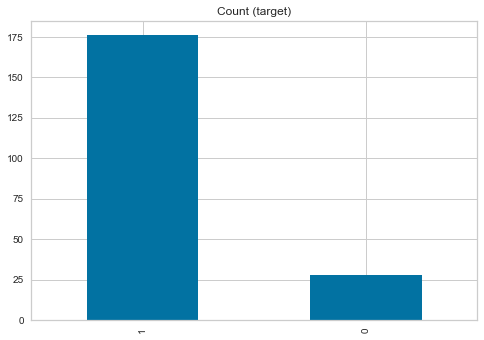

In [15]:
# Classifier 1 : IGPU vs CPU
# Create training set for classifier 1
df_clf_1=df_cleaned.copy()

# Create the target variable for classifier 1
df_clf_1 = df_clf_1.assign(target_class=np.where(df_clf_1['igpu_cpu'] < 1, 0, 1))

# Select only clf_!_top features for training
clf1_columns = clf_1_top + ["target_class"]
df_clf_1 = df_clf_1[clf1_columns]

# Barplot for the distribution of the target class
df_clf_1['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid =True)

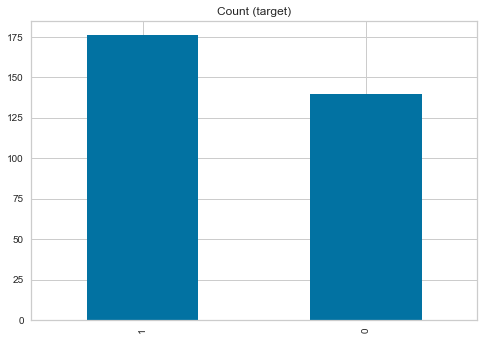

In [16]:
# From the barplot that was created it is evident that we have to deal with imbalanced data. 
# This means that we have many more examples from class 1 (majority class) in the training dataset 
# than from class 0 (minority class). 
# This is going to affect negatively the training process and for this we are going to use the SMOTE 
# in order to oversample the minority class

# Apply SMOTE
smote_df = df_clf_1.drop(columns=["target_class"])
smote = SMOTE(n_jobs=-1, k_neighbors=8, sampling_strategy=0.8, random_state=0)
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_1['target_class'])

df_clf_1_balanced = pd.DataFrame(X_sm, columns=list(df_clf_1.columns))
df_clf_1_balanced['target_class'] = y_sm

# Compare with previous bar plot before SMOTE. Now we have balanced classes. 
df_clf_1_balanced['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

# Final formatting of the training dataset
# X_1 is a pandas dataframe containing the features
# y_1 is a pandas series containg the target class
X_1 = df_clf_1_balanced.drop(columns=["target_class"])
X_columns = df_clf_1_balanced.columns
y_1 = df_clf_1_balanced["target_class"]

# Final formatting of the test dataset
# X_test is a pandas dataframe containing the features that the model expects
X_test = left_out[clf_1_top+['igpu_cpu']]
y_test = X_test.assign(target_class=np.where(X_test['igpu_cpu'] < 1, 0, 1))["target_class"]
X_test = X_test.drop(columns = ['igpu_cpu'])

0.9151209677419356 {'max_depth': 50, 'n_estimators': 100}
Top features:
1. feature 0: threads (0.5187901574324769)
2. feature 1: global_memory_loads (0.11455466823892464)
3. feature 5: global_memory_stores (0.10494300934922621)
4. feature 9: local_memory_loads (0.06535107454332681)
5. feature 2: local_memory_stores (0.0503947605077158)
6. feature 6: total_loops (0.04061185361069964)
7. feature 8: parallel_loops (0.039019842035128476)
8. feature 4: cast_operations (0.027795335478670465)
9. feature 3: vector_operations (0.023526203621484575)
10. feature 7: total_integer_operations (0.015013095182346503)
In-sample accuracy: 1.0, Out-of-sample accuracy:0.8888888888888888


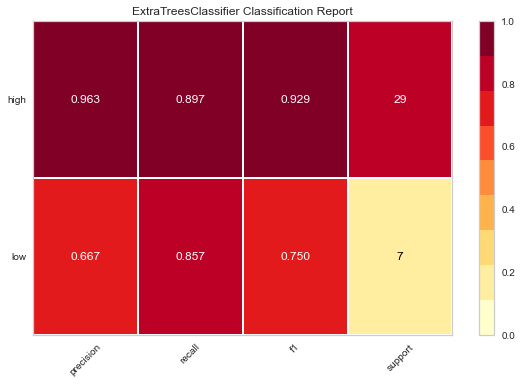

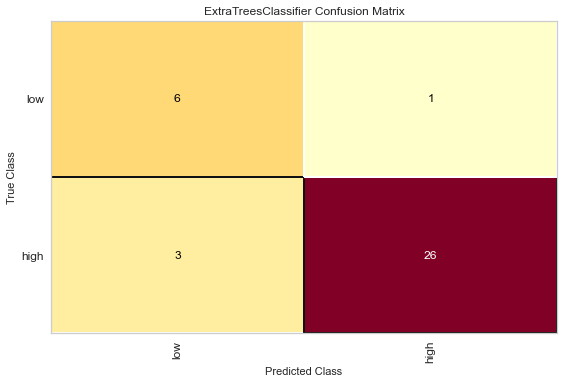

<AxesSubplot:title={'center':'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [17]:
# from yellowbrick.classifier import ClassificationReport, ConfusionMatrix, ROCAUC
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_val_score

# Model training 

train_cols = list(X_1.columns)
# Values per hyperparameter for grid search to search
parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}
# Apply grid search
clf = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf.fit(X_1, y_1)
# Get the best classifier found
forest_1 = clf.best_estimator_
print (clf.best_score_, clf.best_params_) 
forest_1.fit(X_1, y_1)

# Get the feature importance order according to the trained classifier
importances = forest_1.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_1.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')
    
# Make predictions using the trained model for both train and test dataset
# in order to compute in-sample and out-of-sample accuracy
train_preds_1 = forest_1.predict(X_1)
test_preds_1 = forest_1.predict(X_test)

in_sample_acc_1 = accuracy_score(y_1, train_preds_1)
out_sample_acc_1 = accuracy_score(y_test, test_preds_1)
print(f"In-sample accuracy: {in_sample_acc_1}, Out-of-sample accuracy:{out_sample_acc_1}")

# Uncomment to plot feature importances
# plot_feature_importances(train_cols, indices)


# Classification Report
visualizer = ClassificationReport(forest_1, classes=["low", "high"], support=True)
visualizer.fit(X_1, y_1)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show() 

# Confusion Matrix
cm = ConfusionMatrix(forest_1, classes=["low", "high"])
cm.fit(X_1, y_1)
cm.score(X_test, y_test)
cm.show()

In [18]:
# create a dataframe with the per feature importance for classifier 1
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]
clf_1_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_1_imp["model"] ="IGPU vs CPU"
clf_1_imp = clf_1_imp.set_index("model")

print(f"Importance per feature for classifier 1:")
clf_1_imp.head()

Importance per feature for classifier 1:


,threads,global_memory_loads,total_loops,total_integer_operations,global_memory_stores,parallel_loops,vector_operations,local_memory_stores,local_memory_loads,cast_operations
model,,,,,,,,,,
IGPU vs CPU,0.51879,0.114555,0.104943,0.065351,0.050395,0.040612,0.03902,0.027795,0.023526,0.015013


     pred_neg  pred_pos
neg         6         1
pos         1        28


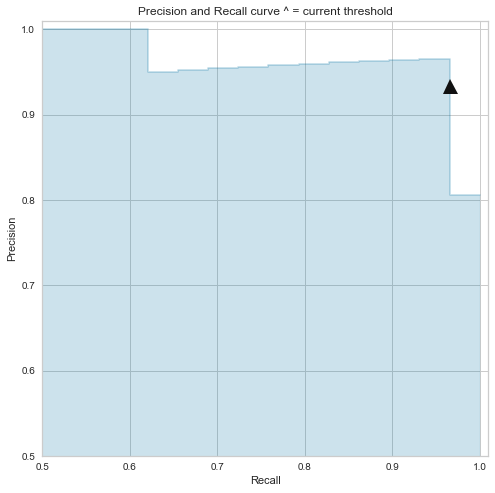

In [19]:
y_scores = forest_1.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, y_test, y_scores, thresholds, 0.2)

# Classifier 2: GPU vs CPU

In [ ]:
df_clf_2=df_cleaned
df_clf_2 = df_clf_2.assign(target_class=np.where(df_clf_2['gpu_cpu'] < 1, 0, 1))

In [ ]:
# classifier 2: GPU vs CPU

clf2_features =clf_2_top
clf2_columns = clf2_features + ["target_class", "workload"]

df_clf_2 = df_cleaned
df_clf_2 = df_clf_2.assign(target_class=np.where(df_clf_2['gpu_cpu'] < 1, 0, 1))
df_clf_2 = df_clf_2.drop(columns=["cpu_time", "igpu_time", "gpu_time", "gpu_igpu", 
                                  "igpu_cpu", "gpu_cpu", "workload_name",
                                  "igpu_gpu"])

df_clf_2 = df_clf_2[clf2_columns]

forest_2_features = list(df_clf_2.columns)

df_clf_2['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)
df_clf_2 = df_clf_2.drop(columns=["workload"])



In [ ]:
# SMOTE for imbalanced class
smote_df = df_clf_2.drop(columns=["target_class"])
smote = SMOTE(n_jobs=-1, k_neighbors=3, sampling_strategy=0.8, random_state=0)
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_2['target_class'])

df_clf_2 = pd.DataFrame(X_sm, columns=list(df_clf_2.columns))
df_clf_2['target_class'] = y_sm

df_clf_2['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

X_2 = df_clf_2.drop(columns=["target_class"])
X_columns = df_clf_2.columns
y_2 = df_clf_2["target_class"]


X_test = left_out[clf2_features+['gpu_cpu']]
y_test = X_test.assign(target_class=np.where(X_test['gpu_cpu'] < 1, 0, 1))
y_test = y_test["target_class"]
X_test = X_test.drop(columns = ['gpu_cpu'])
 

In [ ]:
X_2.columns

In [ ]:
# Specify the target classes
classes = ["low", "high"]

# Instantiate the visualizer
visualizer = RadViz(classes=classes)

visualizer.fit(X_2, y_2)           # Fit the data to the visualizer
visualizer.transform(X_2)        # Transform the data
visualizer.show() 

In [ ]:
from sklearn.model_selection import GridSearchCV

train_cols = list(X_2.columns)

parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}

clf_2 = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf_2.fit(X_2, y_2)
forest_2 = clf_2.best_estimator_
print (clf_2.best_score_, clf_2.best_params_) 
forest_2.fit(X_2, y_2)

importances = forest_2.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_2.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')
    
# predict 
train_preds_2 = forest_2.predict(X_2)
test_preds_2 = forest_2.predict(X_test)

in_sample_acc_2 = accuracy_score(y_2, train_preds_2)
out_sample_acc_2 = accuracy_score(y_test, test_preds_2)

print(f"In-sample accuracy: {in_sample_acc_2}, Out-of-sample accuracy:{out_sample_acc_2}")

plt.figure()
plt.title('Top feature importances')
plt.bar(
    range(len(train_cols)), 
    importances[indices],
    yerr=std[indices], 
)
plt.xticks(range(len(train_cols)), indices)
plt.show()

# Classification Report
visualizer = ClassificationReport(forest_2, classes=["low", "high"], support=True)
visualizer.fit(X_2, y_2)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show() 

# Confusion Matrix
cm = ConfusionMatrix(forest_2, classes=["low", "high"])
cm.fit(X_2, y_2)
cm.score(X_test, y_test)
cm.show()

In [ ]:
y_probas = forest_2.predict_proba(X_test)
plot_roc(y_test, y_probas, title= "GPU vs CPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_2.pdf")
# plt.show()

In [ ]:
y_scores = forest_2.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, thresholds, 0.4)

In [ ]:
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]
clf_2_imp = [importances[i] for i in indices][:10]
clf_2_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_2_imp["model"] ="GPU vs CPU"
clf_2_imp = clf_2_imp.set_index("model")

# Classifier 3: IGPU vs GPU

In [ ]:
df_clf_3=df_cleaned
df_clf_3 = df_clf_3.assign(target_class=np.where(df_clf_3['gpu_igpu'] < 1, 0, 1))


In [ ]:
# classifier 3: GPU vs IGPU
# clf3_features = ["threads", "parallel_loops", "total_loops","cast_operations","local_memory_operations", 
#                  "global_memory_operations", "control_flow_operations", "total_float_operations",
#                 "math_functions"]


clf3_features=clf_3_top
clf3_columns = clf3_features + ["target_class", "workload"]

df_clf_3 = df_cleaned
df_clf_3 = df_clf_3.assign(target_class=np.where(df_clf_3['gpu_igpu'] < 1, 0, 1))
df_clf_3 = df_clf_3.drop(columns=["cpu_time", "igpu_time", "gpu_time", "gpu_igpu", 
                                  "igpu_cpu", "gpu_cpu", "workload_name",
                                  "igpu_gpu"])

df_clf_3 = df_clf_3[clf3_columns]

forest_3_features = list(df_clf_3.columns)

df_clf_3['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)
df_clf_3 = df_clf_3.drop(columns=["workload"])


In [ ]:
# SMOTE for imbalanced class
smote_df = df_clf_3.drop(columns=["target_class"])
smote = SMOTE(n_jobs=-1, sampling_strategy = 0.8, k_neighbors=8)
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_3['target_class'])

df_clf_3 = pd.DataFrame(X_sm, columns=list(df_clf_3.columns))
df_clf_3['target_class'] = y_sm

df_clf_3['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

X_3 = df_clf_3.drop(columns=["target_class"])
X_columns = df_clf_3.columns
y_3 = df_clf_3["target_class"]


X_test = left_out[clf3_features+['gpu_igpu']]
y_test = X_test.assign(target_class=np.where(X_test['gpu_igpu'] < 1, 0, 1))
y_test = y_test["target_class"]
X_test = X_test.drop(columns = ['gpu_igpu'])
 

In [ ]:
X_3.columns

In [ ]:
# Specify the target classes
classes = ["low", "high"]

# Instantiate the visualizer
visualizer = RadViz(classes=classes)

visualizer.fit(X_3, y_3)           # Fit the data to the visualizer
visualizer.transform(X_3)        # Transform the data
visualizer.show() 

In [ ]:
from sklearn.model_selection import GridSearchCV

train_cols = list(X_3.columns)

parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}

clf_3 = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf_3.fit(X_3, y_3)
forest_3 = clf_3.best_estimator_
print (clf_3.best_score_, clf_3.best_params_) 
forest_3.fit(X_3, y_3)

importances = forest_3.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_3.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')
    
# predict 
train_preds_3 = forest_3.predict(X_3)
test_preds_3 = forest_3.predict(X_test)

in_sample_acc_3 = accuracy_score(y_3, train_preds_3)
out_sample_acc_3 = accuracy_score(y_test, test_preds_3)

print(f"In-sample accuracy: {in_sample_acc_3}, Out-of-sample accuracy:{out_sample_acc_3}")

plt.figure()
plt.title('Top feature importances')
plt.bar(
    range(len(train_cols)), 
    importances[indices],
    yerr=std[indices], 
)
plt.xticks(range(len(train_cols)), indices)
plt.show()

# Classification Report
visualizer = ClassificationReport(forest_3, classes=["low", "high"], support=True)
visualizer.fit(X_3, y_3)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show() 

# Confusion Matrix
cm = ConfusionMatrix(forest_3, classes=["low", "high"])
cm.fit(X_3, y_3)
cm.score(X_test, y_test)
cm.show()

In [ ]:
y_probas = forest_3.predict_proba(X_test)
plot_roc(y_test, y_probas, title= "GPU vs IGPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_3.pdf")
# plt.show()

In [ ]:
y_scores = forest_3.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, thresholds, 0.68)

In [ ]:
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]

clf_3_imp = [importances[i] for i in indices][:10]
clf_3_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_3_imp["model"] ="GPU vs IGPU"
clf_3_imp = clf_3_imp.set_index("model")

# Evaluation in held-out data

In [ ]:
# 0.3, 0.4, 0.7 => 8/9 >=baseline
#0.5, 0.4, 0.7

In [ ]:
# experiment_results = {}
workload_experiment = "workload_3_high"

In [ ]:
left_out.set_index("workload").loc[workloads[workload_experiment] , : ].loc[workloads[workload_experiment] , : ]

In [ ]:
workloads["workload_1_low"]=["DFT_1024", "BlackScholes_131072", "MatrixMultiplication1D_256"]
workloads["workload_1_medium"]=["DFT_4096", "BlackScholes_524288", "MatrixMultiplication1D_512"]
workloads["workload_1_high"]=["DFT_32768", "BlackScholes_2097152", "MatrixMultiplication1D_1024"]

workloads["workload_3_low"]=["MatrixTranspose_512", "B&W_64", "Convolution2D_128", "Euler_32"]
workloads["workload_3_medium"]=["MatrixTranspose_1024", "B&W_512", "Convolution2D_512", "Euler_64"]
workloads["workload_3_high"]=["MatrixTranspose_2048", "B&W_2048", "Convolution2D_1024", "Euler_128"]

workloads["workload_2_low"]=["NBody_1024", "Montecarlo_65536", "RenderTrack_128", "Mandelbrot_256", "HilbertMatrix_64"]
workloads["workload_2_medium"]=["NBody_4096", "Montecarlo_524288", "RenderTrack_512", "Mandelbrot_512", "HilbertMatrix_256"]
workloads["workload_2_high"]=["NBody_16384", "Montecarlo_1048576", "RenderTrack_2048", "Mandelbrot_1024", "HilbertMatrix_1024"]

test_set = left_out.set_index("workload").loc[workloads[workload_experiment] , : ].loc[workloads[workload_experiment] , : ]

test_set_1 = test_set[list(X_1.columns)]

test_set_2 = test_set[list(X_2.columns)]

test_set_3 = test_set[list(X_3.columns)]


In [ ]:
test_set_1=test_set_1.reset_index()
test_set_meta=test_set_1[["workload"]]
test_set_1 = test_set_1.drop(columns=["workload"])
test_set_meta

In [ ]:
test_set_meta["igpu_cpu_high_speedup"] = list(pd.DataFrame(forest_1.predict_proba(test_set_1), columns=forest_1.classes_)[1])
test_set_meta["gpu_cpu_high_speedup"] = list(pd.DataFrame(forest_2.predict_proba(test_set_2), columns=forest_2.classes_)[1])
test_set_meta["gpu_igpu_high_speedup"] = list(pd.DataFrame(forest_3.predict_proba(test_set_3), columns=forest_3.classes_)[1])

test_set_meta = test_set_meta.assign(igpu_fit=np.where(test_set_meta['igpu_cpu_high_speedup'] < 0.15, 0, 1))
test_set_meta = test_set_meta.assign(gpu_fit=np.where(test_set_meta['gpu_cpu_high_speedup'] < 0.4, 0, 1))
test_set_meta = test_set_meta.assign(gpu_igpu_fit=np.where(test_set_meta['gpu_igpu_high_speedup'] < 0.67, 0, 1))

# test_set_meta = test_set_meta.assign(gpu_igpu_fit=np.where(test_set_meta['gpu_cpu_high_speedup'] < test_set_meta['igpu_cpu_high_speedup'], 0, 1))

test_set_meta["device"]=test_set_meta["igpu_fit"].map(str)+test_set_meta["gpu_fit"].map(str)+test_set_meta["gpu_igpu_fit"].map(str)
# test_set_meta["device"]=test_set_meta["igpu_fit"].map(str)+test_set_meta["gpu_fit"].map(str)


test_set_meta["device"]=test_set_meta['device'].replace(['001', '000'], 'cpu')
test_set_meta["device"]=test_set_meta['device'].replace(['101', '100', '110'], 'igpu')
test_set_meta["device"]=test_set_meta['device'].replace(['011', '010', '111'], 'gpu')

# test_set_meta["device"]=test_set_meta['device'].replace(['00'], 'cpu')
# test_set_meta["device"]=test_set_meta['device'].replace(['10'], 'igpu')
# test_set_meta["device"]=test_set_meta['device'].replace(['01', '11'], 'gpu')
# test_set_meta["device"]=test_set_meta['device'].replace(['11'], 'gpu')

# test_set_meta['device'] = np.where(((test_set_meta['device']=='gpu')
#                                    & (test_set_meta['igpu_cpu_high_speedup']> test_set_meta['igpu_cpu_high_speedup'])), 'igpu', 'gpu')



In [ ]:
test_set_meta

In [ ]:
scheduling = dict(zip(test_set_meta.workload, test_set_meta.device))

In [ ]:
experiment_results[workload_experiment] = scheduling

In [ ]:
experiment_results

In [ ]:
from joblib import dump, load
dump(forest_1, 'IGPUvsCPU_final.joblib') 
dump(forest_2, 'GPUvsCPU_final.joblib') 
dump(forest_3, 'GPUvsIGPU_final.joblib') 

In [ ]:
classifier_features = {
    "c1": list(X_1.columns),
    "c2": list(X_2.columns),
    "c3": list(X_3.columns)
}

with open('./Final Artifacts/features.txt', 'w') as outfile:
    json.dump(classifier_features, outfile)

# Plots

In [ ]:
feat_imp = pd.concat([clf_1_imp,clf_2_imp, clf_3_imp], axis=0).fillna(0)
feat_imp

In [ ]:
def hinton(matrix, max_weight=None, ax=None):
    """Draw Hinton diagram for visualizing a weight matrix."""
    ax = ax if ax is not None else plt.gca()

    if not max_weight:
        max_weight = 2**np.ceil(np.log(np.abs(matrix).max())/np.log(2))

    ax.patch.set_facecolor('white')
    ax.set_aspect('equal', 'box')
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    for (x, y), w in np.ndenumerate(matrix):
        color = 'black' if w > 0 else 'blue'
        size = np.sqrt(np.abs(w))
        rect = plt.Rectangle([x - size / 2, y - size / 2], size, size,
                             facecolor=color, edgecolor=color)
        ax.add_patch(rect)
        
    for spine in ax.spines.values():
        spine.set_color('lightgray')

    xticks = matrix.shape[0]
    yticks = matrix.shape[1]
    ax.xaxis.tick_top()
    ax.set_xticks(range(xticks))
    ax.set_xticklabels(list(matrix.index), rotation=80, fontsize=15)
    ax.set_yticks(range(yticks))
    ax.set_yticklabels(list(matrix.columns),  rotation=0, fontsize=14)
#     ax.grid(True)
    plt.grid(True)

    ax.autoscale_view()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importances.pdf', bbox_inches='tight')  

In [ ]:
hinton(feat_imp.T)